<a href="https://colab.research.google.com/github/NancyMerciline/NLP_EDC/blob/main/Lab4_Part2_Classification_Sentiment_Topics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 4 - Part 2: Document Classification, Sentiment Analysis & Topic Modeling

**Course:** Natural Language Processing

**Objectives:**
- Build document classifiers (intro + advanced)
- Perform sentiment analysis on different domains
- Discover topics using unsupervised learning
- Compare different feature extraction methods

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Personal Analysis Required

This lab contains questions requiring YOUR personal interpretation.

---

## Use Cases Covered

| Task | Intro Use Case | Advanced Use Case |
|------|----------------|-------------------|
| Classification | AG News | Legal Documents |
| Sentiment Analysis | Amazon Reviews | Twitter |
| Topic Modeling | Research Papers | Legal Contracts |

---

## Setup

In [1]:
# Install required libraries (uncomment if needed)
# !pip install datasets scikit-learn nltk pandas numpy matplotlib seaborn wordcloud gensim

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# NLTK
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.pipeline import Pipeline

# Hugging Face datasets
from datasets import load_dataset

print("Setup complete!")

Setup complete!


In [8]:
# Common preprocessing function
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_simple(text):
    """Basic preprocessing: lowercase, remove punctuation."""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return ' '.join(text.split())

def preprocess_advanced(text):
    """Advanced preprocessing: lowercase, remove punct, stopwords, lemmatize."""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

print("Preprocessing functions ready!")

Preprocessing functions ready!


---

# PART A: Document Classification

We will work with two use cases:
1. **Intro:** News Topic Classification (AG News)
2. **Advanced:** Legal Document Classification (LexGLUE)

## A.1 Intro: News Topic Classification (AG News)

**Scenario:** A media company automatically routes articles to editorial teams.

**Feature Extraction:** TF-IDF

In [2]:
import datasets
import huggingface_hub
import fsspec

print("datasets:", datasets.__version__)
print("huggingface_hub:", huggingface_hub.__version__)
print("fsspec:", fsspec.__version__)

datasets: 3.6.0
huggingface_hub: 0.33.5
fsspec: 2025.3.0


In [3]:
!pip install -q \
datasets==3.6.0 \
huggingface_hub==0.33.5 \
fsspec==2025.3.0 \
gcsfs==2025.3.0

In [4]:
import pandas as pd
from datasets import load_dataset

print("Loading dataset...")
ag_news = load_dataset("ag_news")
print(ag_news)

Loading dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})


In [5]:
# Load dataset
ag_news = load_dataset("ag_news")

# Sample data
ag_train = pd.DataFrame(ag_news["train"]).sample(n=8000, random_state=42)
ag_test = pd.DataFrame(ag_news["test"]).sample(n=2000, random_state=42)

# Label mapping
ag_labels = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech"
}

ag_train["label_name"] = ag_train["label"].map(ag_labels)
ag_test["label_name"] = ag_test["label"].map(ag_labels)

print(f"Train: {len(ag_train)}")
print(f"Test: {len(ag_test)}")
print(ag_train["label_name"].value_counts())

Train: 8000
Test: 2000
label_name
Sports      2074
Sci/Tech    2021
Business    1959
World       1946
Name: count, dtype: int64


In [10]:
# Preprocess
ag_train['text_clean'] = ag_train['text'].apply(preprocess_simple)
ag_test['text_clean'] = ag_test['text'].apply(preprocess_simple)

# TF-IDF Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_ag = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

# Convert text to TF-IDF features
X_train_ag = tfidf_ag.fit_transform(ag_train['text_clean'])
X_test_ag = tfidf_ag.transform(ag_test['text_clean'])

# Labels
y_train_ag = ag_train['label']
y_test_ag = ag_test['label']

print(f"TF-IDF features: {X_train_ag.shape[1]}")
print(f"Training samples: {X_train_ag.shape[0]}")
print(f"Testing samples: {X_test_ag.shape[0]}")

TF-IDF features: 5000
Training samples: 8000
Testing samples: 2000


### Exercise A.1: Train a News Classifier

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# NLTK
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.pipeline import Pipeline

# Hugging Face datasets
from datasets import load_dataset

# TODO: Train a Logistic Regression classifier on AG News
# 1. Create the classifier
# 2. Train it
# 3. Make predictions
# 4. Calculate accuracy and F1-score (macro)

# YOUR CODE HERE
clf_ag = LogisticRegression(random_state=42, solver='liblinear')  # Create LogisticRegression

# Train
clf_ag.fit(X_train_ag, y_train_ag)

# Predict
y_pred_ag = clf_ag.predict(X_test_ag)

# Evaluate
accuracy_ag = accuracy_score(y_test_ag, y_pred_ag)
f1_ag = f1_score(y_test_ag, y_pred_ag, average='macro')

print(f"AG News Classification Results:")
print(f"  Accuracy: {accuracy_ag:.4f}")
print(f"  F1 (macro): {f1_ag:.4f}")

AG News Classification Results:
  Accuracy: 0.8835
  F1 (macro): 0.8827


In [12]:
# Display classification report
print("\nClassification Report:")
print(classification_report(y_test_ag, y_pred_ag, target_names=list(ag_labels.values())))


Classification Report:
              precision    recall  f1-score   support

       World       0.89      0.88      0.89       493
      Sports       0.93      0.96      0.95       504
    Business       0.84      0.82      0.83       474
    Sci/Tech       0.86      0.86      0.86       529

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.88      0.88      2000



## A.2 Advanced: Legal Document Classification (LexGLUE - ECtHR)

**Scenario:** A law firm classifies court decisions by violated articles.

**Feature Extraction:** Bag of Words with N-grams

**Challenge:** Legal text is longer and uses specialized vocabulary.

In [13]:
# Load LexGLUE ECtHR dataset (European Court of Human Rights)
print("Loading LexGLUE ECtHR dataset...")
lex_glue = load_dataset("lex_glue", "ecthr_a")

# Convert to DataFrame
lex_train = pd.DataFrame(lex_glue['train'])
lex_test = pd.DataFrame(lex_glue['test'])

# Use subset (legal docs are long)
lex_train = lex_train.sample(n=min(1500, len(lex_train)), random_state=42)
lex_test = lex_test.sample(n=min(500, len(lex_test)), random_state=42)

print(f"Train: {len(lex_train)}, Test: {len(lex_test)}")
print(f"\nColumns: {lex_train.columns.tolist()}")

Loading LexGLUE ECtHR dataset...


README.md: 0.00B [00:00, ?B/s]

ecthr_a/train-00000-of-00001.parquet:   0%|          | 0.00/42.4M [00:00<?, ?B/s]

ecthr_a/test-00000-of-00001.parquet:   0%|          | 0.00/5.68M [00:00<?, ?B/s]

ecthr_a/validation-00000-of-00001.parque(…):   0%|          | 0.00/5.26M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Train: 1500, Test: 500

Columns: ['text', 'labels']


In [14]:
# Examine the data structure
print("Sample legal document (first 500 chars):")
sample_text = ' '.join(lex_train.iloc[0]['text'][:3])  # text is a list of paragraphs
print(sample_text[:500])

print(f"\nLabels (violated articles): {lex_train.iloc[0]['labels']}")

Sample legal document (first 500 chars):
5.  The applicant, Mr Laszlo Kilyen, was born in 1972 and lives in Murgeşti. 6.  On 10 May 2003 police officers T.M. and L.C.V. were carrying out an investigation into the theft of two cars in the village of Murgeşti. The applicant, who lived alone in a house with a yard, was away from home on a trip abroad. On the same day at around 4 p.m., the two officers entered the applicant’s yard by breaking the main gate which had a closing system made by the applicant from metal wires. The officers took

Labels (violated articles): [4]


In [15]:
# Prepare data: combine text paragraphs and use first label for simplicity
def prepare_legal_text(row):
    """Join text paragraphs and truncate."""
    full_text = ' '.join(row['text'])
    return full_text[:5000]  # Truncate long documents

lex_train['full_text'] = lex_train.apply(prepare_legal_text, axis=1)
lex_test['full_text'] = lex_test.apply(prepare_legal_text, axis=1)

# Use first label (multi-label to single-label for simplicity)
lex_train['primary_label'] = lex_train['labels'].apply(lambda x: x[0] if x else -1)
lex_test['primary_label'] = lex_test['labels'].apply(lambda x: x[0] if x else -1)

# Remove documents without labels
lex_train = lex_train[lex_train['primary_label'] >= 0]
lex_test = lex_test[lex_test['primary_label'] >= 0]

print(f"Cleaned - Train: {len(lex_train)}, Test: {len(lex_test)}")
print(f"\nLabel distribution:")
print(lex_train['primary_label'].value_counts().head(10))

Cleaned - Train: 1340, Test: 428

Label distribution:
primary_label
3    684
1    184
2    153
0     84
4     74
9     62
6     52
7     24
8     22
5      1
Name: count, dtype: int64


### Exercise A.2: Build a Legal Document Classifier

In [18]:
# TODO: Complete the legal document classifier using Bag of Words

# Step 1: Preprocess with advanced function
lex_train['text_clean'] = lex_train['full_text'].apply(preprocess_advanced)
lex_test['text_clean'] = lex_test['full_text'].apply(preprocess_advanced)

# Step 2: Create CountVectorizer (Bag of Words) with bigrams
# YOUR CODE HERE
bow_legal = CountVectorizer(
    max_features=5000,      # Choose: 3000-5000
    ngram_range=(1,2),       # Choose: (1,1), (1,2), or (1,3)
    min_df=5,            # Choose: 2-5
    max_df=0.9             # Choose: 0.9-0.99
)

# Step 3: Transform data
X_train_lex = bow_legal.fit_transform(lex_train['text_clean'])
X_test_lex = bow_legal.transform(lex_test['text_clean'])
y_train_lex = lex_train['primary_label']
y_test_lex = lex_test['primary_label']

print(f"BoW features: {X_train_lex.shape[1]}")

BoW features: 5000


In [20]:
# TODO: Train a Linear SVM classifier (good for high-dimensional legal text) or other model

# YOUR CODE HERE
clf_legal = LinearSVC(random_state=42)  # Create LinearSVC

# Train
clf_legal.fit(X_train_lex, y_train_lex)

# Predict
y_pred_lex = clf_legal.predict(X_test_lex)

# Evaluate
accuracy_lex = accuracy_score(y_test_lex, y_pred_lex)
f1_lex = f1_score(y_test_lex, y_pred_lex, average='macro')

print(f"Legal Classification Results:")
print(f"  Accuracy: {accuracy_lex:.4f}")
print(f"  F1 (macro): {f1_lex:.4f}")

Legal Classification Results:
  Accuracy: 0.6425
  F1 (macro): 0.4951


### Written Question A.1 (Personal Interpretation)

Compare your results from AG News and Legal classification:

1. **Which task achieved higher accuracy?** Why do you think there's a difference?
2. **What vectorizer parameters did you choose for legal text?** Justify each choice.
3. **What challenges are unique to legal document classification?** (Consider: length, vocabulary, ambiguity)

**YOUR ANSWER:**

1. Accuracy comparison:
   - AG News: 0.8835 | Legal: 0.6425
   - Reason for difference: The AG News classification task achieved significantly higher accuracy. This difference can be attributed to several factors:
   - **Nature of Classes:** News categories (World, Sports, Business, Sci/Tech) are generally more distinct and separable than legal classifications, which can often be nuanced and overlap. Legal articles might discuss multiple related concepts.
   - **Language Complexity:** News articles use more general language, whereas legal documents contain highly specialized vocabulary, formal structures, and intricate logical relationships, making them harder for a simple bag-of-words model to capture effectively.
   - **Dataset Size/Balance:** While both datasets were sampled, the underlying complexity and potential class imbalance in legal documents can make learning more challenging.

2. My vectorizer choices:
   - max_features=___ because legal text is rich in specific terminology. 5000 features allow for a broad vocabulary representation without becoming overly sparse or computationally expensive, aiming to capture a good range of specialized terms.
   - ngram_range=___ because legal text often contains important phrases and collocations (e.g., "terms and conditions", "intellectual property"). Including bigrams helps capture these multi-word expressions, which carry more specific meaning than individual words, improving semantic understanding. Unigrams are still crucial for individual word meanings.
   - min_df=___  because it filters out terms that appear in fewer than 5 documents. In a specialized domain like legal text, rare terms might be typos or highly specific instances not relevant for general classification. This helps focus on more common and robust legal concepts.
   - max_df=___ because it excludes terms that appear in more than 90% of the documents. These are typically very common words (even after stop-word removal) that lack discriminative power across different legal categories. Removing them reduces noise and focuses on terms that differentiate between topics.

3. Legal classification challenges:
   -  **Length:** Legal documents are often very long and contain extensive boilerplate language, which can dilute the signal from relevant sections. This requires careful handling like truncation or advanced text processing techniques.
    -  **Vocabulary:** The language is highly specialized, formal, and often archaic. This means common stop-word lists may not be sufficient, and understanding requires deep domain-specific knowledge.
    -  **Ambiguity/Nuance:** Legal language is designed to be precise but can also be highly nuanced and context-dependent. Subtle differences in wording can have significant legal implications, making automated classification challenging due to inherent ambiguity for models without contextual understanding.

---

# PART B: Sentiment Analysis

We will work with two use cases:
1. **Intro:** E-commerce Product Reviews (Amazon)
2. **Advanced:** Social Media Sentiment (Twitter/TweetEval)

## B.1 Intro: Amazon Product Reviews

**Scenario:** An e-commerce company monitors product sentiment.

**Feature Extraction:** TF-IDF

In [23]:
from datasets import load_dataset
import pandas as pd

print("Loading Amazon Polarity dataset...")

amazon = load_dataset("amazon_polarity")

# Convert to DataFrame and sample
amazon_train = pd.DataFrame(amazon["train"]).sample(n=5000, random_state=42)
amazon_test = pd.DataFrame(amazon["test"]).sample(n=1000, random_state=42)

# Create a text column similar to the original dataset
amazon_train["text"] = amazon_train["title"] + " " + amazon_train["content"]
amazon_test["text"] = amazon_test["title"] + " " + amazon_test["content"]

# Create a stars column so the rest of the notebook doesn't break
# 0 (negative) -> 1 star
# 1 (positive) -> 5 stars
amazon_train["stars"] = amazon_train["label"].map({0: 1, 1: 5})
amazon_test["stars"] = amazon_test["label"].map({0: 1, 1: 5})

print(f"Train: {len(amazon_train)}, Test: {len(amazon_test)}")
print("\nColumns:", amazon_train.columns.tolist())
print("\nStar rating distribution:")
print(amazon_train["stars"].value_counts().sort_index())

Loading Amazon Polarity dataset...


README.md: 0.00B [00:00, ?B/s]

amazon_polarity/train-00000-of-00004.par(…):   0%|          | 0.00/260M [00:00<?, ?B/s]

amazon_polarity/train-00001-of-00004.par(…):   0%|          | 0.00/258M [00:00<?, ?B/s]

amazon_polarity/train-00002-of-00004.par(…):   0%|          | 0.00/255M [00:00<?, ?B/s]

amazon_polarity/train-00003-of-00004.par(…):   0%|          | 0.00/254M [00:00<?, ?B/s]

amazon_polarity/test-00000-of-00001.parq(…):   0%|          | 0.00/117M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3600000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/400000 [00:00<?, ? examples/s]

Train: 5000, Test: 1000

Columns: ['label', 'title', 'content', 'text', 'stars']

Star rating distribution:
stars
1    2511
5    2489
Name: count, dtype: int64


In [24]:
# Convert to binary sentiment (1-2 stars = negative, 4-5 stars = positive)
# Remove neutral (3 stars) for clearer distinction

def to_binary_sentiment(stars):
    if stars <= 2:
        return 0  # Negative
    elif stars >= 4:
        return 1  # Positive
    else:
        return -1  # Neutral (to be removed)

amazon_train['sentiment'] = amazon_train['stars'].apply(to_binary_sentiment)
amazon_test['sentiment'] = amazon_test['stars'].apply(to_binary_sentiment)

# Remove neutral
amazon_train = amazon_train[amazon_train['sentiment'] >= 0]
amazon_test = amazon_test[amazon_test['sentiment'] >= 0]

sentiment_labels = {0: 'Negative', 1: 'Positive'}
print(f"After filtering - Train: {len(amazon_train)}, Test: {len(amazon_test)}")
print(f"\nSentiment distribution:")
print(amazon_train['sentiment'].value_counts())

After filtering - Train: 5000, Test: 1000

Sentiment distribution:
sentiment
0    2511
1    2489
Name: count, dtype: int64


In [28]:
print("Sample POSITIVE review:")
pos_sample = amazon_train[amazon_train['sentiment'] == 1].iloc[0]
print(f"Review: {pos_sample['text'][:300]}...")

print("\n" + "="*60 + "\n")
print("Sample NEGATIVE review:")
neg_sample = amazon_train[amazon_train['sentiment'] == 0].iloc[0]
print(f"Review: {neg_sample['text'][:300]}...")

Sample POSITIVE review:
Review: Excellent imagery...dumbed down story I enjoyed this disc. The video is stunning. I agree with others that the story is very dumbed down and takes a childish approach. It actually seems like its a little one sided and VERY pro-environmental. Nevertheless its enjoyable. I would say however that the A...


Sample NEGATIVE review:
Review: Expensive Junk This product consists of a piece of thin flexible insulating material, adhesive backed velcro and white electrical tape.Problems:1. Instructions are three pictures with little more information.2. Velcro was all crumpled as received and was stronger than the adhesive. When i tried to d...


### Exercise B.1: Build Amazon Sentiment Classifier

In [29]:
# TODO: Build sentiment classifier for Amazon reviews

# Step 1: Preprocess
amazon_train['text_clean'] = amazon_train['text'].apply(preprocess_simple)
amazon_test['text_clean'] = amazon_test['text'].apply(preprocess_simple)

# Step 2: TF-IDF
tfidf_amazon = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X_train_amz = tfidf_amazon.fit_transform(amazon_train['text_clean'])
X_test_amz = tfidf_amazon.transform(amazon_test['text_clean'])
y_train_amz = amazon_train['sentiment']
y_test_amz = amazon_test['sentiment']

# Step 3 & 4: Train Naive Bayes and evaluate or choose another model if not suitable
clf_amazon = MultinomialNB()  # Create MultinomialNB

# Train
clf_amazon.fit(X_train_amz, y_train_amz)

# Predict
y_pred_amz = clf_amazon.predict(X_test_amz)

# Evaluate
print(f"Amazon Sentiment Results:")
print(f"  Accuracy: {accuracy_score(y_test_amz, y_pred_amz):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_amz, y_pred_amz, target_names=['Negative', 'Positive']))

Amazon Sentiment Results:
  Accuracy: 0.8380

Classification Report:
              precision    recall  f1-score   support

    Negative       0.84      0.83      0.84       496
    Positive       0.84      0.85      0.84       504

    accuracy                           0.84      1000
   macro avg       0.84      0.84      0.84      1000
weighted avg       0.84      0.84      0.84      1000



In [30]:
# Analyze most predictive words
feature_names = tfidf_amazon.get_feature_names_out()

# For Naive Bayes, use log probabilities
neg_probs = clf_amazon.feature_log_prob_[0]
pos_probs = clf_amazon.feature_log_prob_[1]
log_ratio = pos_probs - neg_probs

# Top positive and negative words
top_pos_idx = log_ratio.argsort()[-15:]
top_neg_idx = log_ratio.argsort()[:15]

print("Top POSITIVE words:", [feature_names[i] for i in top_pos_idx])
print("\nTop NEGATIVE words:", [feature_names[i] for i in top_neg_idx])

Top POSITIVE words: ['favorite', 'perfect', 'enjoyable', 'loves', 'parent', 'great', 'helps', 'awesome', 'wonderfully', 'amazing', 'rocks', 'fantastic', 'easy', 'wonderful', 'excellent']

Top NEGATIVE words: ['waste', 'poor', 'horrible', 'boring', 'worst', 'terrible', 'junk', 'disappointment', 'wasted', 'sorry', 'garbage', 'poorly', 'return', 'disappointing', 'useless']


## B.2 Advanced: Twitter Sentiment (TweetEval)

**Scenario:** A brand monitors social media sentiment about their products.

**Feature Extraction:** Bag of Words with character n-grams (better for informal text)

**Challenge:** Tweets are short, informal, with hashtags, mentions, and slang.

In [31]:
# Load TweetEval sentiment dataset
print("Loading TweetEval Sentiment dataset...")
tweet_eval = load_dataset("tweet_eval", "sentiment")

tweet_train = pd.DataFrame(tweet_eval['train'])
tweet_test = pd.DataFrame(tweet_eval['test'])

# Labels: 0=negative, 1=neutral, 2=positive
tweet_labels = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
tweet_train['label_name'] = tweet_train['label'].map(tweet_labels)
tweet_test['label_name'] = tweet_test['label'].map(tweet_labels)

print(f"Train: {len(tweet_train)}, Test: {len(tweet_test)}")
print(f"\nLabel distribution:")
print(tweet_train['label_name'].value_counts())

Loading TweetEval Sentiment dataset...


README.md: 0.00B [00:00, ?B/s]

sentiment/train-00000-of-00001.parquet:   0%|          | 0.00/3.78M [00:00<?, ?B/s]

sentiment/test-00000-of-00001.parquet:   0%|          | 0.00/901k [00:00<?, ?B/s]

sentiment/validation-00000-of-00001.parq(…):   0%|          | 0.00/167k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Train: 45615, Test: 12284

Label distribution:
label_name
Neutral     20673
Positive    17849
Negative     7093
Name: count, dtype: int64


In [32]:
# Sample tweets
for label in [0, 1, 2]:
    sample = tweet_train[tweet_train['label'] == label].iloc[0]
    print(f"[{tweet_labels[label]}]: {sample['text']}\n")

[Negative]: So disappointed in wwe summerslam! I want to see john cena wins his 16th title

[Neutral]: "Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ"

[Positive]: "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"



In [33]:
# Special preprocessing for tweets
def preprocess_tweet(text):
    """Preprocess tweet text."""
    text = str(text).lower()
    # Keep @mentions and #hashtags but simplify
    text = re.sub(r'@\w+', '@user', text)  # Replace mentions with @user
    text = re.sub(r'http\S+', 'URL', text)  # Replace URLs
    text = re.sub(r'[^a-zA-Z@#\s]', '', text)  # Keep @ and # symbols
    return ' '.join(text.split())

tweet_train['text_clean'] = tweet_train['text'].apply(preprocess_tweet)
tweet_test['text_clean'] = tweet_test['text'].apply(preprocess_tweet)

print("Sample preprocessed tweet:")
print(f"Original: {tweet_train.iloc[0]['text']}")
print(f"Cleaned:  {tweet_train.iloc[0]['text_clean']}")

Sample preprocessed tweet:
Original: "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"
Cleaned:  qt @user in the original draft of the th book remus lupin survived the battle of hogwarts #happybirthdayremuslupin


### Exercise B.2: Build Twitter Sentiment Classifier

In [34]:
# TODO: Build a classifier using character n-grams (good for short, informal text)

# YOUR CODE HERE: Create a vectorizer with character n-grams
# Hint: Use analyzer='char_wb' for word-boundary-aware character n-grams

char_vectorizer = TfidfVectorizer(
    analyzer='char_wb',           # 'char_wb' for character n-grams with word boundaries
    ngram_range=(2,5),        # Try (2,5) or (3,6) for character n-grams
    max_features=5000,       # 3000-5000
    min_df=5              # 2-5
)

X_train_tw = char_vectorizer.fit_transform(tweet_train['text_clean'])
X_test_tw = char_vectorizer.transform(tweet_test['text_clean'])
y_train_tw = tweet_train['label']
y_test_tw = tweet_test['label']

print(f"Character n-gram features: {X_train_tw.shape[1]}")

Character n-gram features: 5000


In [35]:
clf_tweet = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)  # Create LogisticRegression

# Train
clf_tweet.fit(X_train_tw, y_train_tw)

# Predict
y_pred_tw = clf_tweet.predict(X_test_tw)

# Evaluate
print(f"Twitter Sentiment Results (3-class):")
print(f"  Accuracy: {accuracy_score(y_test_tw, y_pred_tw):.4f}")
print(f"  F1 (macro): {f1_score(y_test_tw, y_pred_tw, average='macro'):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_tw, y_pred_tw, target_names=list(tweet_labels.values())))

Twitter Sentiment Results (3-class):
  Accuracy: 0.5746
  F1 (macro): 0.5381

Classification Report:
              precision    recall  f1-score   support

    Negative       0.70      0.30      0.42      3972
     Neutral       0.58      0.74      0.65      5937
    Positive       0.49      0.61      0.54      2375

    accuracy                           0.57     12284
   macro avg       0.59      0.55      0.54     12284
weighted avg       0.60      0.57      0.56     12284



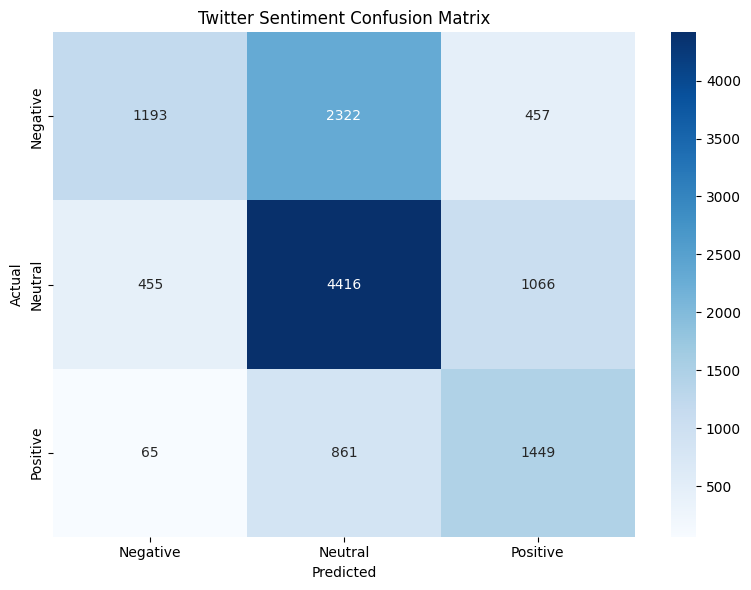

In [36]:
# Confusion matrix
cm_tw = confusion_matrix(y_test_tw, y_pred_tw)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_tw, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(tweet_labels.values()),
            yticklabels=list(tweet_labels.values()))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Twitter Sentiment Confusion Matrix')
plt.tight_layout()
plt.savefig('twitter_sentiment_cm.png', dpi=150)
plt.show()

### Written Question B.1 (Personal Interpretation)

Compare Amazon vs Twitter sentiment analysis:

1. **Which task was harder?** Look at the F1 scores and confusion matrices.
2. **Why did you choose those character n-gram parameters for Twitter?** What's the advantage over word n-grams?
3. **Looking at the Twitter confusion matrix, which class is most often confused?** Why might this be?
4. **Give an example tweet that would be hard to classify correctly.** Explain why.

**YOUR ANSWER:**

1. Harder task:
   - Amazon F1: 0.8400 | Twitter F1: 0.5381
   - Reason: The Twitter sentiment analysis task was significantly harder, as evidenced by its much lower F1 score (0.5381) compared to Amazon (0.8400). This is primarily due to the nature of the data. Tweets are inherently short, informal, often contain slang, emojis, abbreviations, sarcasm, and highly contextual language. The 3-class classification (Negative, Neutral, Positive) also adds complexity compared to the binary classification for Amazon reviews. The sparsity and noise in Twitter data make it much more challenging for traditional text classification models to extract clear sentiment signals.

2. Character n-gram choices:
   - ngram_range=(2,5) because for short, informal texts like tweets, character n-grams can capture sub-word information, common misspellings, and patterns that are not full words (e.g., 'lol', 'wtf', ':)'). An `ngram_range` of (2,5) captures combinations of 2 to 5 characters, which is a good balance to get useful patterns without creating too many features from very long character sequences.
   - Advantage over words: Character n-grams are robust to misspellings and variations (e.g., 'goood' vs 'good' would share 'oo' and 'ooo' n-grams). They can also capture sentiment cues embedded in short, non-word tokens (like '!!!' or ':(' or hashtags like '#sad'). For informal text where word boundaries are less strict and vocabulary is highly dynamic, character n-grams often provide a more stable and informative feature set than traditional word n-grams, which can struggle with out-of-vocabulary words or highly varied informal language.

3. Most confused class:
   - Class: The **Neutral** class is most often confused, acting as a 'catch-all' for ambiguous cases or tweets lacking strong sentiment indicators. As seen in the confusion matrix, actual Neutral tweets are frequently misclassified, with a significant portion being predicted as Positive (1066 instances) or Negative (455 instances). This difficulty in distinguishing neutral from other sentiments often arises because neutral tweets can contain elements that lean slightly positive or negative, or they may simply lack strong affective language, making them harder for the model to confidently assign to a single sentiment category. Additionally, many tweets are genuinely factual or descriptive, which are inherently neutral but might contain terms that appear in positive or negative contexts elsewhere. The model's tendency to misclassify neutral tweets into the positive category more often could suggest a slight positive bias, or that positive language is sometimes subtle enough to be confused with neutrality.

---

# PART C: Topic Modeling

We will work with two use cases:
1. **Intro:** Research Paper Topics (ArXiv)
2. **Advanced:** Legal Contract Topics

## C.1 Intro: Research Paper Topic Discovery (ArXiv)

**Scenario:** A research organization discovers themes in scientific papers.

**Method:** LDA (Latent Dirichlet Allocation)

In [39]:
# Load ArXiv papers dataset
print("Loading ArXiv papers dataset (this may take a moment)...")
arxiv = load_dataset("scientific_papers", "arxiv", trust_remote_code=True)

# Sample from training set
arxiv_df = pd.DataFrame(arxiv['train']).sample(n=2000, random_state=42)

print(f"Loaded {len(arxiv_df)} papers")
print(f"Columns: {arxiv_df.columns.tolist()}")

Loading ArXiv papers dataset (this may take a moment)...


Generating train split:   0%|          | 0/203037 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/6436 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6440 [00:00<?, ? examples/s]

Loaded 2000 papers
Columns: ['article', 'abstract', 'section_names']


In [41]:
# Examine sample
print("Sample paper abstract (first 500 chars):")
print(arxiv_df.iloc[0]['abstract'][:500])

Sample paper abstract (first 500 chars):
 we study the effect of @xmath0-symmetric complex potentials on the transport properties of non - hermitian systems , which consist of an infinite linear chain and two side - coupled defect points with @xmath0-symmetric complex on - site potentials . by analytically solving the scattering problem of two typical models , 
 which display standard fano resonances in the absence of non - hermitian terms , we find that the @xmath0-symmetric imaginary potentials can lead to some pronounced effects on 


In [45]:
# Preprocess abstracts for topic modeling
arxiv_df['abstract_clean'] = arxiv_df['abstract'].apply(preprocess_advanced)

# Create document-term matrix with CountVectorizer
count_vec_arxiv = CountVectorizer(
    max_features=5000,      # Example parameter: maximum features
    stop_words='english'  # Example parameter: remove common English stop words
)

dtm_arxiv = count_vec_arxiv.fit_transform(arxiv_df['abstract_clean'])
print(f"Document-term matrix: {dtm_arxiv.shape}")

Document-term matrix: (2000, 5000)


In [46]:
# Train LDA model
n_topics_arxiv = 10  # Scientific papers likely have diverse topics. Choose appropriately (8-12).

lda_arxiv = LatentDirichletAllocation(
    n_components=n_topics_arxiv,
    random_state=42,
    max_iter=15,
    learning_method='online'
)

print("Training LDA on ArXiv papers...")
lda_arxiv.fit(dtm_arxiv)
print("Done!")

Training LDA on ArXiv papers...
Done!


In [47]:
# Display topics
def display_lda_topics(model, feature_names, n_words=12):
    """Display top words for each LDA topic."""
    for topic_idx, topic in enumerate(model.components_):
        top_words_idx = topic.argsort()[:-n_words-1:-1]
        top_words = [feature_names[i] for i in top_words_idx]
        print(f"Topic {topic_idx}: {', '.join(top_words)}")

feature_names_arxiv = count_vec_arxiv.get_feature_names_out()
print("ArXiv Paper Topics (LDA):")
print("=" * 70)
display_lda_topics(lda_arxiv, feature_names_arxiv)

ArXiv Paper Topics (LDA):
Topic 0: xmath, galaxy, ray, mass, star, source, emission, observation, black, line, redshift, hole
Topic 1: xmath, mass, physic, decay, university, gev, production, event, channel, section, cross, higgs
Topic 2: xmath, xcite, state, fig, quantum, field, phase, transition, spin, value, energy, temperature
Topic 3: energy, model, spin, field, magnetic, electron, effect, result, polarization, structure, spectrum, nuclear
Topic 4: star, xmath, neutrino, model, dark, matter, solar, field, mass, stellar, abundance, magnetic
Topic 5: cluster, network, disk, structure, layer, surface, cloak, stokes, size, object, line, inner
Topic 6: model, equation, theory, method, field, quark, solution, potential, result, order, non, function
Topic 7: noise, frequency, flow, energy, time, measurement, beam, simulation, mechanical, experiment, high, phase
Topic 8: xmath, space, graph, number, set, xcite, problem, result, bound, dimension, case, matrix
Topic 9: network, model, algor

### Exercise C.1: Interpret ArXiv Topics

In [48]:
# TODO: Assign meaningful labels to each topic based on the keywords

my_arxiv_topic_labels = {
    0: "Astrophysics/Cosmology",  # YOUR LABEL
    1: "Particle Physics",  # YOUR LABEL
    2: "Condensed Matter/Quantum Physics",  # YOUR LABEL
    3: "Material Science/Magnetic Properties",  # YOUR LABEL
    4: "Stellar Physics/Dark Matter",  # YOUR LABEL
    5: "Complex Physical Systems/Simulation",  # YOUR LABEL
    6: "Theoretical Physics/Mathematical Methods",  # YOUR LABEL
    7: "Experimental Physics/Signal Processing",  # YOUR LABEL
    8: "Mathematics/Graph Theory",  # YOUR LABEL
    9: "Computer Science/Networking"  # YOUR LABEL
    # Add more if n_topics_arxiv > 8
}

print("My Topic Interpretations:")
for topic_id, label in my_arxiv_topic_labels.items():
    if label != "___":
        print(f"  Topic {topic_id}: {label}")

My Topic Interpretations:
  Topic 0: Astrophysics/Cosmology
  Topic 1: Particle Physics
  Topic 2: Condensed Matter/Quantum Physics
  Topic 3: Material Science/Magnetic Properties
  Topic 4: Stellar Physics/Dark Matter
  Topic 5: Complex Physical Systems/Simulation
  Topic 6: Theoretical Physics/Mathematical Methods
  Topic 7: Experimental Physics/Signal Processing
  Topic 8: Mathematics/Graph Theory
  Topic 9: Computer Science/Networking


## C.2 Advanced: Legal Contract Topic Discovery

**Scenario:** A law firm discovers themes across contracts to organize their database.

**Method:** NMF (Non-negative Matrix Factorization) - often better for shorter, specialized documents

**Challenge:** Legal language is formal and domain-specific.

In [ ]:
# Load legal contracts dataset (streaming to handle large size)
print("Loading Legal Contracts dataset...")
legal_stream = load_dataset("albertvillanova/legal_contracts", split="train", streaming=True)

# Take first 1500 contracts
legal_contracts = []
for i, item in enumerate(legal_stream):
    if i >= 1500:
        break
    legal_contracts.append(item)

legal_df = pd.DataFrame(legal_contracts)
print(f"Loaded {len(legal_df)} contracts")

Loading Legal Contracts dataset...


legal_contracts.py: 0.00B [00:00, ?B/s]

The repository for albertvillanova/legal_contracts contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/albertvillanova/legal_contracts.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


In [50]:
# Preprocess legal text (truncate long documents)
legal_df['text_truncated'] = legal_df['text'].str[:8000]  # Truncate
legal_df['text_clean'] = legal_df['text_truncated'].apply(preprocess_advanced)

print("Sample contract (cleaned, first 300 chars):")
print(legal_df.iloc[0]['text_clean'][:300])

Sample contract (cleaned, first 300 chars):
quicklinks click rapidly navigate document amended restated employment noncompetition agreement amended restated employment noncompetition agreement agreement made entered october among avocent employment service formerly known polycon investment inc texas corporation employer avocent corporation de


### Exercise C.2: Build NMF Topic Model for Legal Contracts

In [52]:
tfidf_legal = TfidfVectorizer(
    max_features=5000, # Example parameter, adjust as needed
    stop_words='english',
    ngram_range=(1,2) # NMF often benefits from n-grams, especially in specialized text
)

dtm_legal = tfidf_legal.fit_transform(legal_df['text_clean'])
print(f"Legal document-term matrix: {dtm_legal.shape}")

Legal document-term matrix: (1500, 5000)


In [53]:
# TODO: Train NMF model
# Choose number of topics (legal contracts may have: employment, confidentiality, IP, services, etc.)

n_topics_legal = 8  # YOUR CHOICE: 5-12

nmf_legal = NMF(
    n_components=n_topics_legal,
    random_state=42,
    max_iter=200
)

print(f"Training NMF with {n_topics_legal} topics...")
nmf_legal.fit(dtm_legal)
print("Done!")

Training NMF with 8 topics...
Done!


In [55]:
# Display NMF topics
def display_nmf_topics(model, feature_names, n_words=12):
    """Display top words for each NMF topic."""
    for topic_idx, topic in enumerate(model.components_):
        top_words_idx = topic.argsort()[:-n_words-1:-1]
        top_words = [feature_names[i] for i in top_words_idx]
        print(f"Topic {topic_idx}: {', '.join(top_words)}")

feature_names_legal = tfidf_legal.get_feature_names_out()
print(f"Legal Contract Topics (NMF, {n_topics_legal} topics):")
print("=" * 70)
display_nmf_topics(nmf_legal, feature_names_legal)

Legal Contract Topics (NMF, 8 topics):
Topic 0: executive, company, employment, shall, executive shall, agreement, salary, benefit, base salary, termination, base, bonus
Topic 1: borrower, loan, credit, lender, agreement, credit agreement, bank, agent, amendment, section, loan agreement, administrative agent
Topic 2: option, plan, stock, share, committee, participant, award, shall, company, mean, common stock, stock option
Topic 3: employee, company, employment, agreement, shall, employee shall, bonus, termination, employer, employment agreement, salary, employee employment
Topic 4: seller, buyer, agreement, purchase, purchaser, share, shall, closing, party, purchase agreement, property, schedule
Topic 5: tenant, landlord, lease, rent, premise, lessee, building, lessor, shall, term, base rent, commencement date
Topic 6: company, voting, change control, control, business combination, security, change, director, voting security, board, person, combination
Topic 7: note, maker, principal,

In [56]:
# TODO: Assign labels to legal topics

my_legal_topic_labels = {
    0: "Executive Employment Agreement",
    1: "Loan/Credit Agreement",
    2: "Stock Option/Equity Plan",
    3: "Employee Employment Agreement",
    4: "Purchase/Sale Agreement",
    5: "Lease Agreement",
    6: "Corporate Governance/Control",
    7: "Promissory Note/Debt"
}  # Add your labels: {0: "label", 1: "label", ...}

# YOUR CODE HERE - fill the dictionary
# for i in range(n_topics_legal):
#     my_legal_topic_labels[i] = "___"  # Replace with your labels

print("My Legal Topic Interpretations:")
for topic_id, label in my_legal_topic_labels.items():
    if label != "___":
        print(f"  Topic {topic_id}: {label}")

My Legal Topic Interpretations:
  Topic 0: Executive Employment Agreement
  Topic 1: Loan/Credit Agreement
  Topic 2: Stock Option/Equity Plan
  Topic 3: Employee Employment Agreement
  Topic 4: Purchase/Sale Agreement
  Topic 5: Lease Agreement
  Topic 6: Corporate Governance/Control
  Topic 7: Promissory Note/Debt


### Exercise C.3: Topic Distribution Visualization

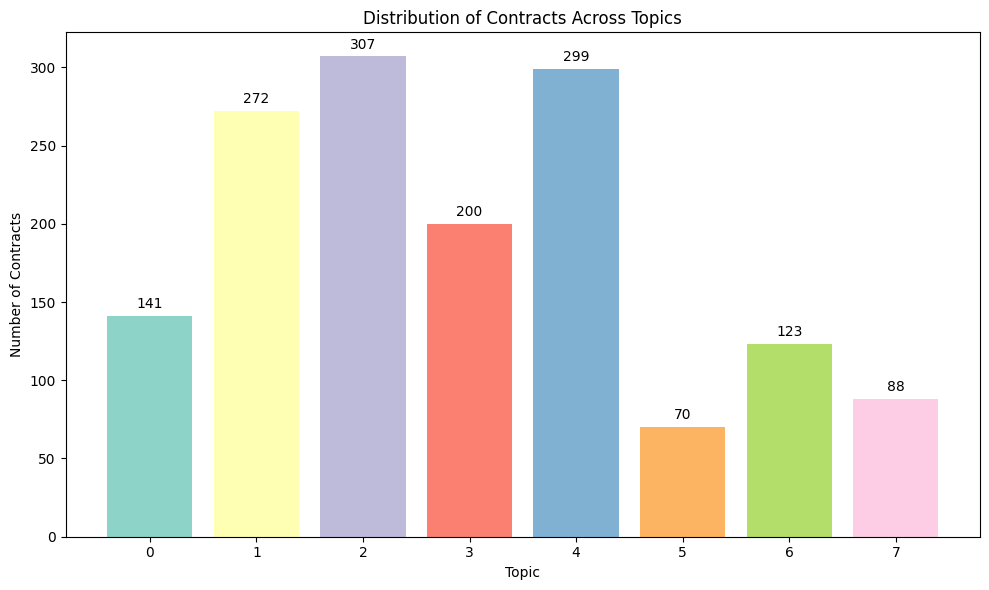

In [57]:
# Get document-topic distributions
doc_topics_legal = nmf_legal.transform(dtm_legal)

# Assign dominant topic
legal_df['dominant_topic'] = doc_topics_legal.argmax(axis=1)

# Visualize topic distribution
plt.figure(figsize=(10, 6))
topic_counts = legal_df['dominant_topic'].value_counts().sort_index()
bars = plt.bar(topic_counts.index, topic_counts.values, color=plt.cm.Set3(range(len(topic_counts))))
plt.xlabel('Topic')
plt.ylabel('Number of Contracts')
plt.title('Distribution of Contracts Across Topics')
plt.xticks(range(n_topics_legal))

# Add count labels
for bar, count in zip(bars, topic_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('legal_topic_distribution.png', dpi=150)
plt.show()

### Written Question C.1 (Personal Interpretation)

Compare ArXiv (LDA) vs Legal Contracts (NMF) topic modeling:

1. **Which set of topics was easier to interpret?** Why?
2. **Looking at the legal topic distribution, is it balanced?** What does this tell you about the contract dataset?
3. **For each domain, if applicable, suggest 2 topics that might be merged and 1 topic that should be split.** Justify.

**YOUR ANSWER:**

1. Easier to interpret:
   - Domain: **Legal Contracts (NMF)** was easier to interpret.
   - Reason: The NMF topics for legal contracts were generally more distinct and cohesive, with keywords that clearly pointed to specific types of legal documents or clauses (e.g., "Loan/Credit Agreement", "Lease Agreement", "Executive Employment Agreement"). This is likely due to the highly structured and domain-specific nature of legal text, which NMF is often well-suited to capture. In contrast, while the LDA topics for ArXiv papers were interpretable, some, particularly in physics, had more overlapping keywords (e.g., 'xmath', 'mass', 'field') that required more careful consideration to differentiate, indicating a broader and sometimes more intertwined subject matter.

2. Legal topic distribution:
   - Balanced? No, the legal topic distribution is **not very balanced**.
   - What this indicates: The plot shows a significant variation in the number of contracts assigned to each dominant topic. For example, Topic 2 ("Stock Option/Equity Plan") and Topic 4 ("Purchase/Sale Agreement") have a much higher number of contracts compared to topics like Topic 5 ("Lease Agreement") or Topic 7 ("Promissory Note/Debt"). This imbalance suggests that the dataset of legal contracts is not evenly distributed across different types of legal documents. It could reflect the prevalence of certain contract types in the source data (e.g., more purchase agreements than lease agreements) or indicate that some topics cover broader categories of documents than others. For analysis or model training, this imbalance might require special handling, such as oversampling smaller classes or using evaluation metrics that are robust to class imbalance.

3. Topic refinement suggestions:
   - ArXiv - Merge: Topics **0 (Astrophysics/Cosmology)** and **4 (Stellar Physics/Dark Matter)** because both deal with celestial bodies, mass, and cosmic phenomena. While distinct, some papers might bridge these, and a combined 'Astronomy/Cosmology' topic might provide a more coherent, higher-level theme. Also, Topics **2 (Condensed Matter/Quantum Physics)** and **3 (Material Science/Magnetic Properties)** could potentially be merged into a broader 'Condensed Matter Physics/Materials' topic, as 'magnetic' properties are a key aspect of condensed matter.
   - ArXiv - Split: Topic **6 (Theoretical Physics/Mathematical Methods)** because it seems to be a catch-all for abstract theoretical concepts and mathematical tools. This topic could likely be split into more specific sub-domains of theoretical physics (e.g., 'Quantum Field Theory' or 'Statistical Mechanics') or separate 'Mathematical Methods' topics, as the keywords like 'model', 'equation', 'theory', and 'function' are very general.
   - Legal - Merge: Topics **0 (Executive Employment Agreement)** and **3 (Employee Employment Agreement)** because both are employment agreements. The distinction between 'executive' and 'employee' might be too fine-grained for a broad topic model, and merging them into a single 'Employment Agreements' topic could provide a more general overview. The core contractual elements (salary, termination, bonus) are similar.
   - Legal - Split: Topic **6 (Corporate Governance/Control)** because keywords like 'company', 'voting', 'change control', and 'business combination' suggest this topic covers a wide range of corporate actions and governance structures. It could potentially be split into more specific topics like 'Mergers & Acquisitions/Business Combinations' and 'Shareholder Rights/Voting Agreements' to capture distinct legal aspects within corporate law.

---

## Summary - Lab 4 Part 2

### Methods Summary

| Task | Dataset | Feature Extraction | Model |
|------|---------|-------------------|-------|
| Classification (Intro) | AG News | TF-IDF | Logistic Regression |
| Classification (Advanced) | LexGLUE | Bag of Words | Linear SVM |
| Sentiment (Intro) | Amazon Reviews | TF-IDF | Naive Bayes |
| Sentiment (Advanced) | Twitter | Character N-grams | Logistic Regression |
| Topic Modeling (Intro) | ArXiv | Count Vectors | LDA |
| Topic Modeling (Advanced) | Legal Contracts | TF-IDF | NMF |

### Key Takeaways

- **Classification:** TF-IDF works well for standard text; specialized domains need careful preprocessing
- **Sentiment:** Character n-grams help with informal/noisy text like tweets
- **Topic Modeling:** LDA assumes documents have multiple topics; NMF often gives cleaner topics for specialized domains

---

## Submission Checklist

- [ ] All code exercises completed (fill all `___` placeholders)
- [ ] **All written questions answered with YOUR personal interpretation**
- [ ] All visualizations saved (PNG files)
- [ ] Notebook saved
- [ ] Pushed to Git repository
- [ ] **Repository link sent to: yoroba93@gmail.com**
